In [1]:
#Importing Basic Libraries
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier


In [3]:
#Evaluation Metrics
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#Loading Dataset
data = pd.read_csv("ML-EdgeIIoT-dataset.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_19192\975571690.py:2: DtypeWarning: Columns (3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("ML-EdgeIIoT-dataset.csv")


In [5]:
print(data.dtypes)

frame.time             object
ip.src_host            object
ip.dst_host            object
arp.dst.proto_ipv4     object
arp.opcode            float64
                       ...   
mbtcp.len             float64
mbtcp.trans_id        float64
mbtcp.unit_id         float64
Attack_label            int64
Attack_type            object
Length: 63, dtype: object


In [6]:
#Cheking for missing values
print("Missing values per column: ")
print(data.isnull().sum())

Missing values per column: 
frame.time            0
ip.src_host           0
ip.dst_host           0
arp.dst.proto_ipv4    0
arp.opcode            0
                     ..
mbtcp.len             0
mbtcp.trans_id        0
mbtcp.unit_id         0
Attack_label          0
Attack_type           0
Length: 63, dtype: int64


In [7]:
#No missing values
#Converting mixed type columns to consistent types
#List of columns with mixed types
mixed_cols = [3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55]
# Convert to string
for col in mixed_cols:
    data.iloc[:, col] = data.iloc[:, col].astype(str)


In [8]:
# Detect all object/string columns
object_cols = data.select_dtypes(include=['object']).columns

# Encode them to numeric
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  

In [9]:
# See mapping of attack type
for cls, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(encoded, "→", cls)


0 → Backdoor
1 → DDoS_HTTP
2 → DDoS_ICMP
3 → DDoS_TCP
4 → DDoS_UDP
5 → Fingerprinting
6 → MITM
7 → Normal
8 → Password
9 → Port_Scanning
10 → Ransomware
11 → SQL_injection
12 → Uploading
13 → Vulnerability_scanner
14 → XSS


In [10]:
print(data.dtypes)  
print(data.head())


frame.time              int32
ip.src_host             int32
ip.dst_host             int32
arp.dst.proto_ipv4      int32
arp.opcode            float64
                       ...   
mbtcp.len             float64
mbtcp.trans_id        float64
mbtcp.unit_id         float64
Attack_label            int64
Attack_type             int32
Length: 63, dtype: object
   frame.time  ip.src_host  ip.dst_host  arp.dst.proto_ipv4  arp.opcode  \
0      153888         8153            1                   1         0.0   
1      153888         8151            1                   1         0.0   
2      153888         8153            1                   1         0.0   
3      153888         8151            1                   1         0.0   
4      153888         8153            1                   1         0.0   

   arp.hw.size  arp.src.proto_ipv4  icmp.checksum  icmp.seq_le  \
0          0.0                   1            0.0          0.0   
1          0.0                   1            0.0          0.

In [11]:
# Remove columns that contain only a single unique value
constant_columns = [col for col in data.columns if data[col].nunique() <= 1]

print("Removing constant columns:", constant_columns)

data = data.drop(columns=constant_columns)


Removing constant columns: ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'dns.retransmit_request_in', 'mqtt.msg_decoded_as', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id']


In [12]:
#Seperating features and Labels
X = data.drop(['Attack_label','Attack_type'], axis=1)
y_label = data['Attack_label']
y_type = data['Attack_type']

In [13]:
print(X.head)


<bound method NDFrame.head of         frame.time  ip.src_host  ip.dst_host  arp.dst.proto_ipv4  arp.opcode  \
0           153888         8153            1                   1         0.0   
1           153888         8151            1                   1         0.0   
2           153888         8153            1                   1         0.0   
3           153888         8151            1                   1         0.0   
4           153888         8153            1                   1         0.0   
...            ...          ...          ...                 ...         ...   
157795      139160         8280         3506                   0         0.0   
157796      139161        13363         3506                   0         0.0   
157797      139162         1070         3506                   0         0.0   
157798      139163        17619         3506                   0         0.0   
157799      139164         4556         3506                   0         0.0   

        a

In [14]:
print(y_type.head)

<bound method NDFrame.head of 0         6
1         6
2         6
3         6
4         6
         ..
157795    2
157796    2
157797    2
157798    2
157799    2
Name: Attack_type, Length: 157800, dtype: int32>


In [15]:
X_train, X_temp, ylabel_train, ylabel_temp, ytype_train, ytype_temp = train_test_split(X, y_label, y_type, test_size = 0.2, random_state =42)

In [16]:
X_val,X_test,ylabel_val,ylabel_test,ytype_val,ytype_test = train_test_split(X_temp,ylabel_temp,ytype_temp, test_size=0.5, random_state=42)

In [17]:
train_rows = X_train.shape[0]
val_rows = X_val.shape[0]
test_rows = X_test.shape[0]

In [18]:
print( train_rows, val_rows, test_rows)

126240 15780 15780


In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform (X_test)

In [20]:
clf_label = RandomForestClassifier(n_estimators=100, random_state=42)
clf_label.fit(X_train, ylabel_train)

RandomForestClassifier(random_state=42)

In [21]:
ylabel_val_pred = clf_label.predict(X_val)
print("=== Validation: Attack Label Prediction ===")
print("Accuracy:", accuracy_score(ylabel_val, ylabel_val_pred))
print(classification_report(ylabel_val, ylabel_val_pred))


=== Validation: Attack Label Prediction ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2497
           1       1.00      1.00      1.00     13283

    accuracy                           1.00     15780
   macro avg       1.00      1.00      1.00     15780
weighted avg       1.00      1.00      1.00     15780



In [22]:
ylabel_test_pred = clf_label.predict(X_test)
print("\n=== Test: Attack Label Prediction ===")
print("Accuracy:", accuracy_score(ylabel_test, ylabel_test_pred))
print(classification_report(ylabel_test, ylabel_test_pred))



=== Test: Attack Label Prediction ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2488
           1       1.00      1.00      1.00     13292

    accuracy                           1.00     15780
   macro avg       1.00      1.00      1.00     15780
weighted avg       1.00      1.00      1.00     15780



In [23]:
#Predicting attack type
train_attack_indices = ylabel_train == 1
val_attack_indices = ylabel_val_pred == 1
test_attack_indices = ylabel_test_pred == 1

In [24]:
X_train_type = X_train[train_attack_indices]
y_train_type = ytype_train[train_attack_indices]

In [25]:
X_val_type = X_val[val_attack_indices]
y_val_type = ytype_val[val_attack_indices]

In [26]:

X_test_type = X_test[test_attack_indices]
y_test_type = ytype_test[test_attack_indices]


In [27]:
clf_type = RandomForestClassifier(n_estimators=100, random_state=42)
clf_type.fit(X_train_type, y_train_type)


RandomForestClassifier(random_state=42)

In [28]:
# Validation predictions for attack type
y_val_pred_type = clf_type.predict(X_val_type)
print("\n=== Validation: Attack Type ===")
print("Accuracy:", accuracy_score(y_val_type, y_val_pred_type))
print(classification_report(y_val_type, y_val_pred_type))





=== Validation: Attack Type ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       991
           1       1.00      1.00      1.00      1016
           2       1.00      1.00      1.00      1453
           3       1.00      1.00      1.00       974
           4       1.00      1.00      1.00      1400
           5       1.00      1.00      1.00       102
           6       1.00      1.00      1.00       139
           8       1.00      1.00      1.00      1018
           9       1.00      1.00      1.00      1072
          10       1.00      1.00      1.00      1027
          11       1.00      1.00      1.00      1054
          12       1.00      1.00      1.00      1011
          13       1.00      1.00      1.00      1033
          14       1.00      1.00      1.00       993

    accuracy                           1.00     13283
   macro avg       1.00      1.00      1.00     13283
weighted avg       1.00      1.00

In [29]:
y_test_pred_type = clf_type.predict(X_test_type)
print("\n=== Test: Attack Type ===")
print("Accuracy:", accuracy_score(y_test_type, y_test_pred_type))
print(classification_report(y_test_type, y_test_pred_type))


=== Test: Attack Type ===
Accuracy: 0.9998495335540174
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       982
           1       1.00      1.00      1.00      1113
           2       1.00      1.00      1.00      1383
           3       1.00      1.00      1.00       987
           4       1.00      1.00      1.00      1504
           5       1.00      1.00      1.00        95
           6       1.00      1.00      1.00       116
           8       1.00      1.00      1.00       955
           9       1.00      1.00      1.00      1056
          10       1.00      1.00      1.00      1034
          11       1.00      1.00      1.00      1035
          12       1.00      1.00      1.00      1004
          13       1.00      1.00      1.00       976
          14       1.00      1.00      1.00      1052

    accuracy                           1.00     13292
   macro avg       1.00      1.00      1.00     13292
weighted avg       1.00 

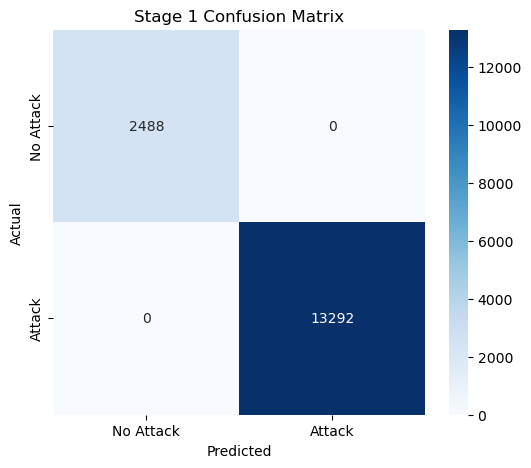

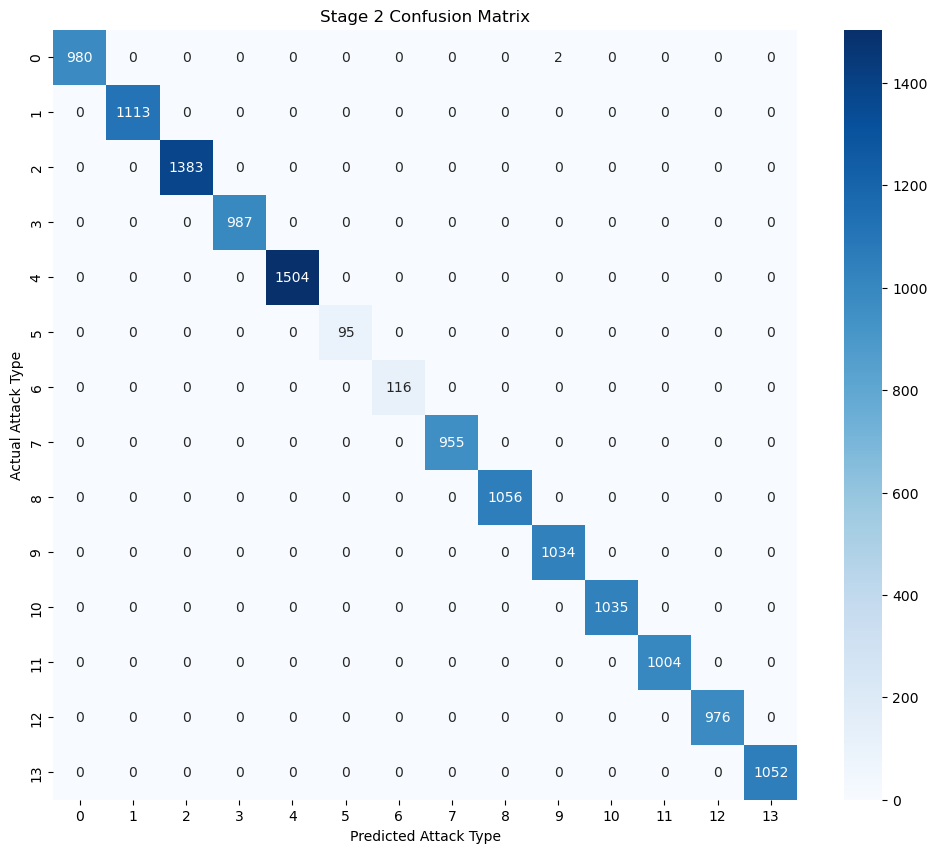

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

#Confusion matrix for stage 01
cm_stage1 = confusion_matrix(ylabel_test, ylabel_test_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(cm_stage1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attack', 'Attack'],
            yticklabels=['No Attack', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage 1 Confusion Matrix")
plt.show()



#For stage 2
cm_stage2 = confusion_matrix(y_test_type, y_test_pred_type)


plt.figure(figsize=(12, 10))
sns.heatmap(cm_stage2, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Attack Type")
plt.ylabel("Actual Attack Type")
plt.title("Stage 2 Confusion Matrix")
plt.show()

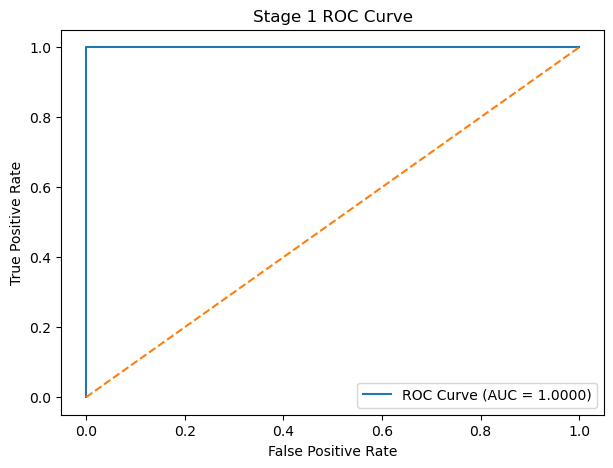

Stage 1 ROC-AUC Score: 1.0


In [31]:
#For stage 1
y_test_prob_stage1 = clf_label.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(ylabel_test, y_test_prob_stage1)
auc_stage1 = roc_auc_score(ylabel_test, y_test_prob_stage1)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_stage1:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage 1 ROC Curve")
plt.legend()
plt.show()

print("Stage 1 ROC-AUC Score:", auc_stage1)

In [32]:
#Stage 2
# Get probabilities for each class
y_test_prob_stage2 = clf_type.predict_proba(X_test_type)

# Convert true labels to binary format
classes_stage2 = np.unique(y_train_type)   
y_test_type_bin = label_binarize(y_test_type, classes=classes_stage2)

# Compute macro ROC-AUC
auc_stage2 = roc_auc_score(
    y_test_type_bin,
    y_test_prob_stage2,
    multi_class='ovr',
    average='macro'
)

print("Stage 2 Multiclass ROC-AUC Score:", auc_stage2)

Stage 2 Multiclass ROC-AUC Score: 1.0


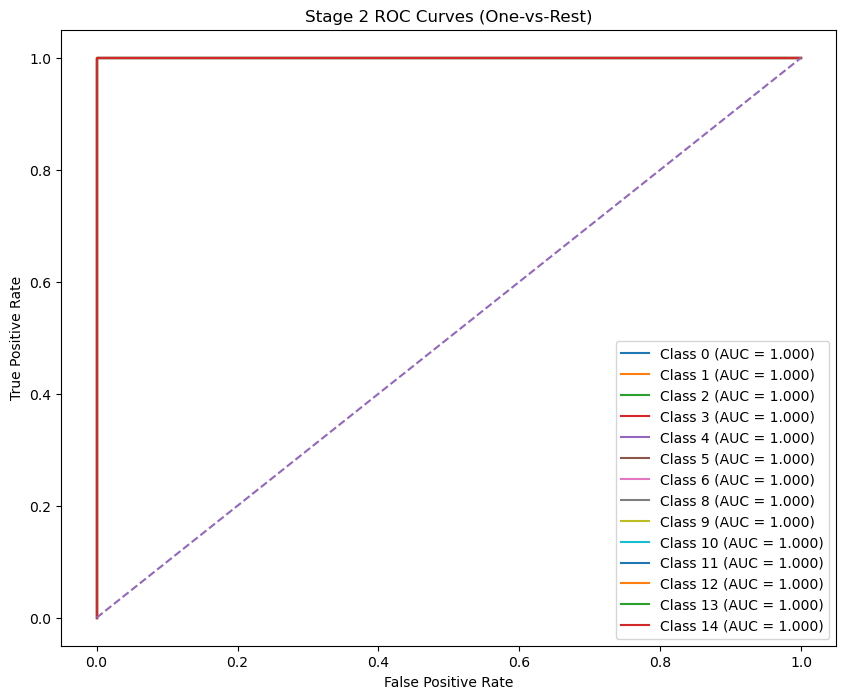

In [33]:
# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i, class_label in enumerate(classes_stage2):
    fpr_i, tpr_i, _ = roc_curve(y_test_type_bin[:, i], y_test_prob_stage2[:, i])
    auc_i = roc_auc_score(y_test_type_bin[:, i], y_test_prob_stage2[:, i])
    plt.plot(fpr_i, tpr_i, label=f"Class {class_label} (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage 2 ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

Final Overall Accuracy: 0.9998732572877059

=== Final Classification Report ===
                       precision    recall  f1-score   support

               Normal       1.00      1.00      1.00      2488
             Backdoor       1.00      1.00      1.00       982
            DDoS_HTTP       1.00      1.00      1.00      1113
            DDoS_ICMP       1.00      1.00      1.00      1383
             DDoS_TCP       1.00      1.00      1.00       987
             DDoS_UDP       1.00      1.00      1.00      1504
       Fingerprinting       1.00      1.00      1.00        95
                 MITM       1.00      1.00      1.00       116
             Password       1.00      1.00      1.00       955
        Port_Scanning       1.00      1.00      1.00      1056
           Ransomware       1.00      1.00      1.00      1034
        SQL_injection       1.00      1.00      1.00      1035
            Uploading       1.00      1.00      1.00      1004
Vulnerability_scanner       1.00     

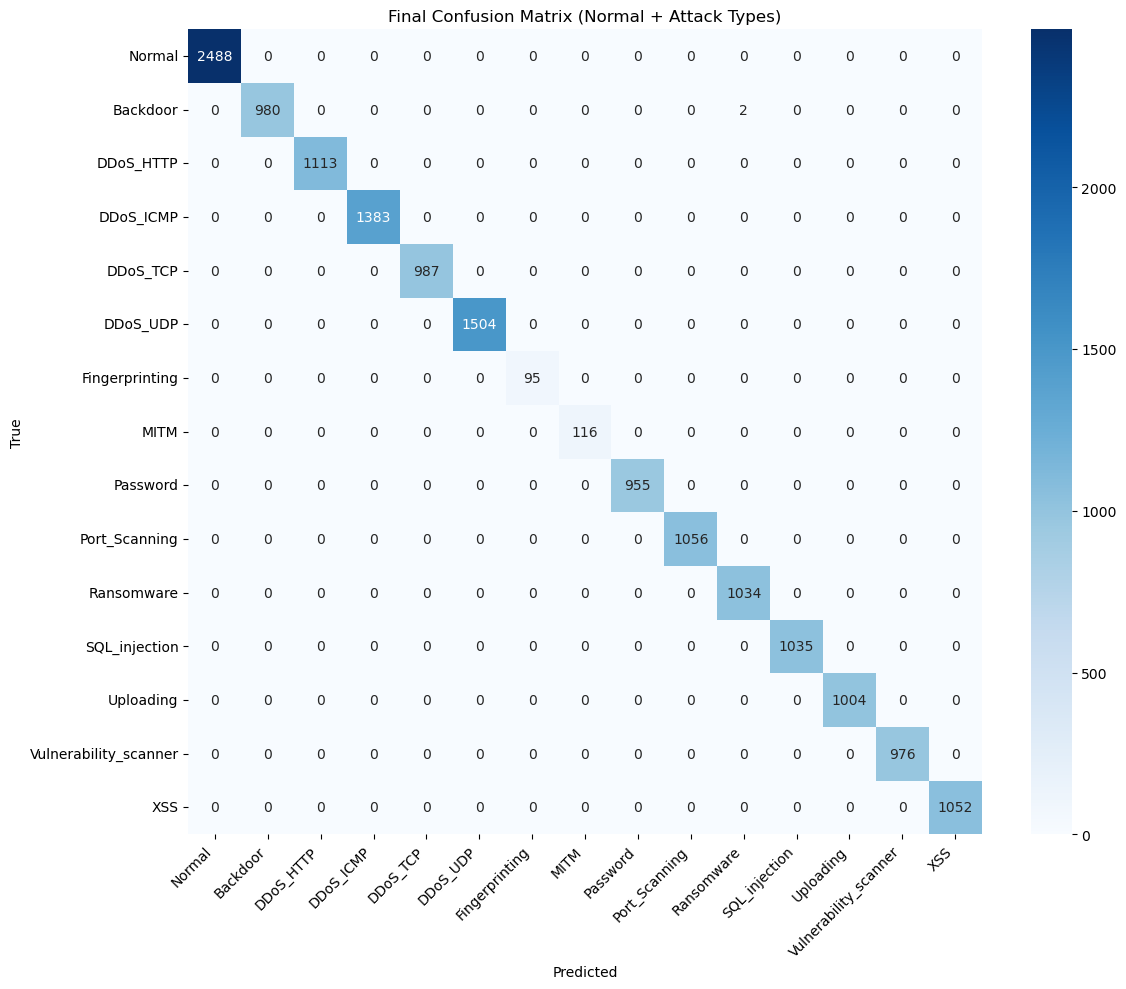

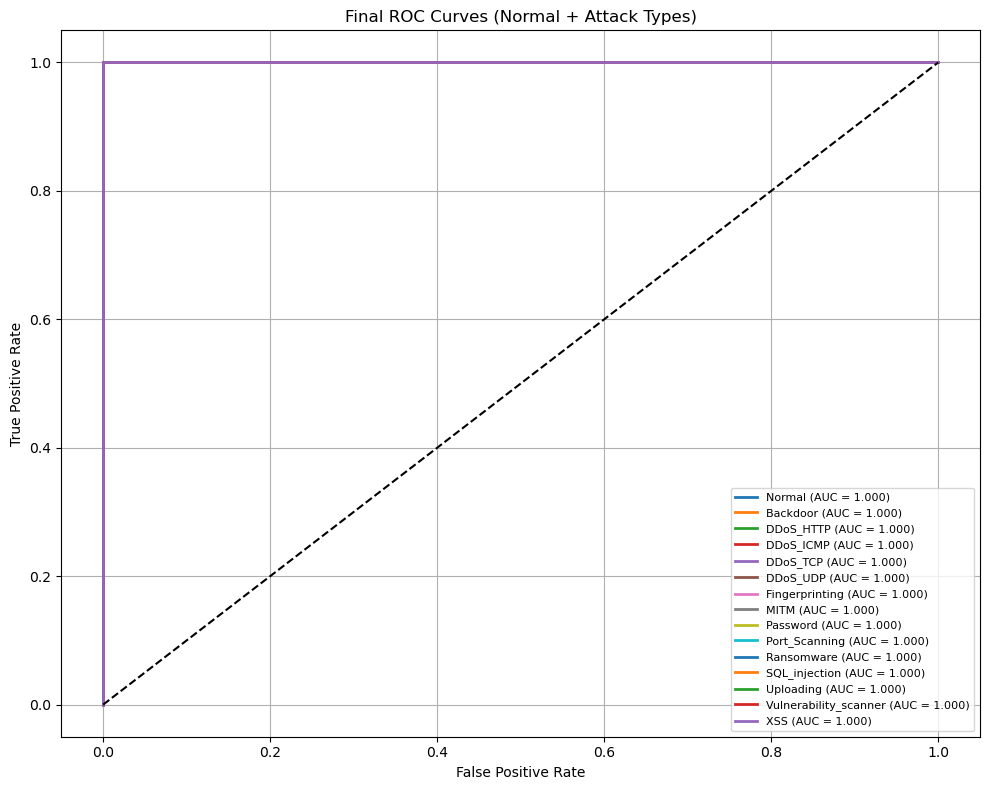


 AUC Scores 
Normal: 1.0000
Backdoor: 1.0000
DDoS_HTTP: 1.0000
DDoS_ICMP: 1.0000
DDoS_TCP: 1.0000
DDoS_UDP: 1.0000
Fingerprinting: 1.0000
MITM: 1.0000
Password: 1.0000
Port_Scanning: 1.0000
Ransomware: 1.0000
SQL_injection: 1.0000
Uploading: 1.0000
Vulnerability_scanner: 1.0000
XSS: 1.0000


In [36]:

# FINAL OUTPUT: NORMAL + ATTACK TYPES
# CONFUSION MATRIX + CLASSIFICATION REPORT + ROC/AUC

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
-
# Attack_type label encoder
attack_type_le = label_encoders['Attack_type']

# Attack_label classes 
# If your Attack_label is already numeric, this still works
label_classes = np.unique(ylabel_train)

normal_label = 0
attack_label = 1


# Probability of being Normal / Attack from first Random Forest
stage1_probs = clf_label.predict_proba(X_test)

# Find the correct column positions
stage1_class_to_index = {cls: i for i, cls in enumerate(clf_label.classes_)}

normal_prob = stage1_probs[:, stage1_class_to_index[normal_label]]
attack_prob = stage1_probs[:, stage1_class_to_index[attack_label]]

# Predict attack-type probabilities for ALL test samples
# (even though stage 2 was trained only on attacks)
stage2_probs = clf_type.predict_proba(X_test)

# Attack classes used by stage 2
stage2_attack_classes_encoded = clf_type.classes_
stage2_attack_names = attack_type_le.inverse_transform(stage2_attack_classes_encoded)


# Final class list = Normal + all attack names used by stage 2
final_classes = np.array(["Normal"] + list(stage2_attack_names))

# Probability matrix for final output
final_probs = np.zeros((len(X_test), len(final_classes)))

# Fill normal probability
final_probs[:, 0] = normal_prob

# Fill attack-type probabilities
# Final probability of each attack type =
# P(Attack from stage 1) * P(Attack type from stage 2)
for i, attack_name in enumerate(stage2_attack_names):
    final_probs[:, i + 1] = attack_prob * stage2_probs[:, i]


final_pred_indices = np.argmax(final_probs, axis=1)
final_output = final_classes[final_pred_indices]


# If true label is normal -> "Normal"
# Else convert encoded attack type back to attack name
y_true_final = []

for lbl, atk_type in zip(ylabel_test, ytype_test):
    if lbl == normal_label:
        y_true_final.append("Normal")
    else:
        y_true_final.append(attack_type_le.inverse_transform([atk_type])[0])

y_true_final = np.array(y_true_final)


final_accuracy = accuracy_score(y_true_final, final_output)
print("Final Overall Accuracy:", final_accuracy)


print("\n=== Final Classification Report ===")
print(classification_report(y_true_final, final_output, labels=final_classes, zero_division=0))


cm_final = confusion_matrix(y_true_final, final_output, labels=final_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_classes, yticklabels=final_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Final Confusion Matrix (Normal + Attack Types)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


y_true_bin = label_binarize(y_true_final, classes=final_classes)

plt.figure(figsize=(10, 8))

auc_scores = {}

for i, class_name in enumerate(final_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], final_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[class_name] = roc_auc
    plt.plot(fpr, tpr, linewidth=2, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curves (Normal + Attack Types)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


print("\n AUC Scores ")
for class_name, score in auc_scores.items():
    print(f"{class_name}: {score:.4f}")